# Q2 K-Means Clusteing

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

## 2.1 Implement a K-Means Class

In [7]:
class KMeans:
    """
    KMeans clustering algorithm.
    """
    def __init__(self, n_clusters=3, max_iters=100000, tol=1e-6):
        """
        Initialize the KMeans instance.
        """
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
    
    def fit(self, X):
        """ 
        Fit the KMeans model to the data X.
        """
        np.random.seed(42)
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iters):
            distances = self._compute_distances(X) 
            labels = np.argmin(distances, axis=1)

            old_centroids = self.centroids.copy()

            for k in range(self.n_clusters):
                if np.any(labels == k):  # Avoid empty clusters
                    self.centroids[k] = X[labels == k].mean(axis=0)

            if np.linalg.norm(self.centroids - old_centroids) < self.tol:
                break

    def _compute_distances(self, X):
        """
        Compute the Euclidean distance from each point in X to each centroid.
        """
        return np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
    
    def predict(self, X):
        """ 
        Predict the closest cluster each sample in X belongs to.
        """
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)
    
    def getCost(self, X):
        """
        Compute the total cost (inertia) of the current clustering.
        """
        distances = self._compute_distances(X)
        labels = np.argmin(distances, axis=1)
        cost = 0
        for k in range(self.n_clusters):
            cost += np.sum((X[labels == k] - self.centroids[k]) ** 2)
        return cost


Centroids:
 [[-0.19543414 -0.0365131 ]
 [-1.33350702  1.12526936]
 [-1.33095185 -1.14480241]
 [ 0.97774284  1.20459994]
 [ 1.04708129 -1.32408255]]
WCSS (Cost): 69.21402873995842
   CustomerID  Cluster
0           1        2
1           2        3
2           3        2
3           4        1
4           5        2


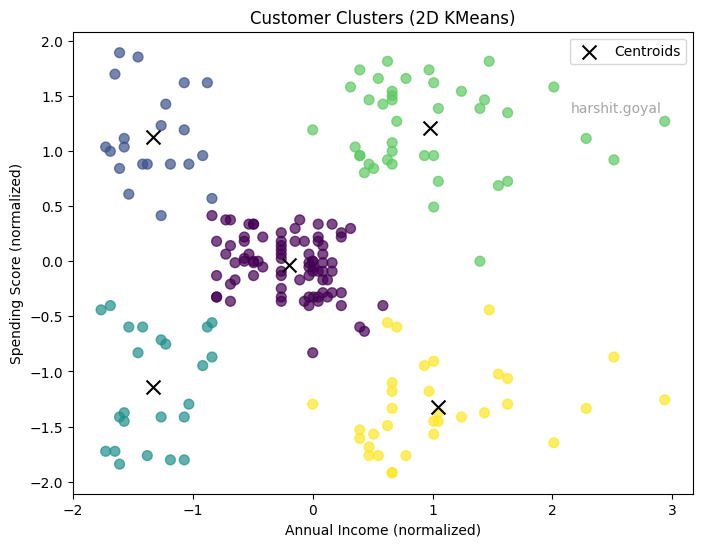

In [8]:
df = pd.read_csv('./Dataset/Q2/Clustering_dataset(in).csv')

customer_ids = df["CustomerID"]
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].mean())
df['Spending Score (1-100)'] = df['Spending Score (1-100)'].fillna(df['Spending Score (1-100)'].mean())
df['Genre'] = df['Genre'].fillna(df['Genre'].mode()[0])

df['isMale'] = [1 if val == 'Male' else 0 for val in df['Genre']]
df.drop(columns=['Genre','CustomerID','isMale','Age'], inplace=True)

# df.info() # df.isnull().sum() # df.describe() # df.duplicated().sum()  # df.corr()
# df.head()

X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
X = (X - X.mean(axis=0)) / X.std(axis=0)

# apply KMeans
kmeans = KMeans(n_clusters=5, max_iters=100000, tol=1e-4)
kmeans.fit(X)
clusters = kmeans.predict(X)
results = pd.DataFrame({
    "CustomerID": customer_ids,
    "Cluster": clusters
})

print("Centroids:\n", kmeans.centroids)
print("WCSS (Cost):", kmeans.getCost(X))
print(results.head())
plt.figure(figsize=(8,6))
plt.scatter(
    X[:, 0], X[:, 1], 
    c=clusters,  s=50, alpha=0.7
)
plt.scatter(
    kmeans.centroids[:, 0], kmeans.centroids[:, 1], 
    c="black", marker="x", s=100, label="Centroids"
)
plt.text(
    0.95, 0.85, "harshit.goyal",
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.xlabel("Annual Income (normalized)")
plt.ylabel("Spending Score (normalized)")
plt.title("Customer Clusters (2D KMeans)")
plt.legend()
plt.show()

## 2.2 Determine the Optimal Number of Clusters

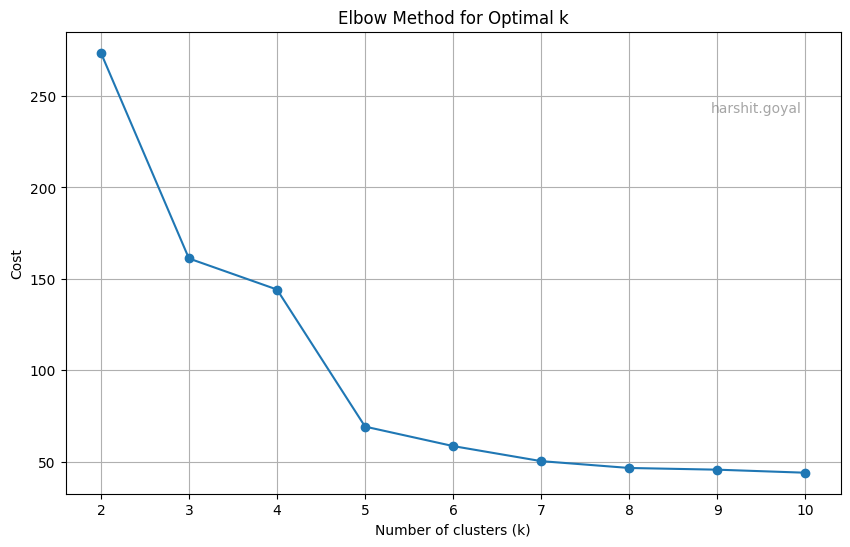

In [15]:
costs = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, max_iters=100000, tol=1e-6)
    kmeans.fit(X)
    cost = kmeans.getCost(X)
    costs.append(cost)

# plotting cost vs k
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(2, 11), costs, marker='o')
ax.set_ylabel('Cost')
ax.set_xlabel('Number of clusters (k)')
ax.set_title('Elbow Method for Optimal k')
ax.set_xticks(range(2, 11))
ax.text(0.95, 0.85, "harshit.goyal",ha='right', va='top',transform=ax.transAxes,fontsize=10, color='gray', alpha=0.7)
ax.grid()

- From the Elbow Method plot, we observe that the Within-Cluster Sum of Squares (WCSS) decreases sharply up to k = 5, after which the rate of decrease slows down significantly. This indicates that adding more clusters beyond 5 does not provide substantial improvement in explaining the variance. Therefore, the optimal number of clusters according to the Elbow Method is k = 5.

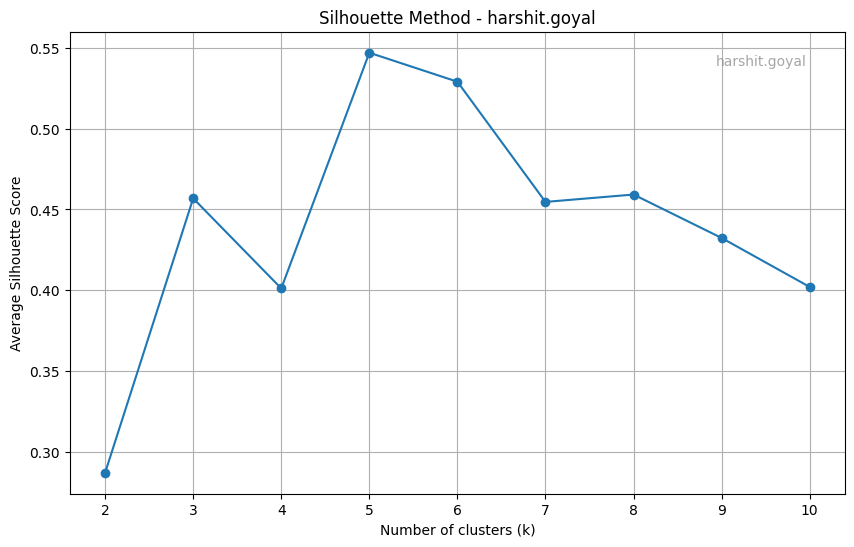

In [17]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, max_iters=100000, tol=1e-6)
    kmeans.fit(X)
    labels = kmeans.predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(2, 11), silhouette_scores, marker='o')
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Average Silhouette Score")
ax.set_title("Silhouette Method - harshit.goyal")
ax.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=ax.transAxes,fontsize=10, color='gray', alpha=0.7)
ax.grid()

- From the Silhouette Method plot, we observe that the average silhouette score reaches its maximum at k = 5. This indicates that the clusters formed at this value are well-separated as compared to other values of k. Hence, the optimal number of clusters according to the Silhouette Method is k = 5, which also supports the result obtained from the Elbow Method.
#### What can you say about the clusters obtained at the optimal value?
- At the optimal value of k = 5, the dataset is partitioned into five well-defined clusters. The high silhouette score indicates that the data points within each cluster are densely packed and well-separated from other clusters. This suggests that the clustering structure effectively captures the underlying patterns in the data, ensuring both compactness within clusters and clear distinction across clusters.